In [33]:
import mlflow
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn import linear_model
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('SCD')


<Experiment: artifact_location='mlflow-artifacts:/0', creation_time=1779782786199, experiment_id='0', last_update_time=1779786251550, lifecycle_stage='active', name='SCD', tags={}, trace_location=None, workspace='default'>

In [ ]:
#Import data and convert the variable types to the correct format for modeling
scd = pd.read_excel('full_data.xlsx')
columns_to_clean = ['ACR','Creatinine','Alb/mg/l']
for col in columns_to_clean:
    if col in scd.columns:
        scd[col] = scd[col].astype(str).str.replace('<', '').str.replace('>', '')
scd['Creatinine'] = pd.to_numeric(scd['Creatinine'],errors = 'coerce')
scd['Alb/mg/l'] = pd.to_numeric(scd['Alb/mg/l'],errors = 'coerce')
scd['ACR'] = pd.to_numeric(scd['ACR'],errors = 'coerce')
# Clean and normalize GENDER values
scd['GENDER'] = scd['GENDER'].astype(str).str.strip().str.upper()
# Normalize common full words to single-letter codes
scd['GENDER'] = scd['GENDER'].replace({'FEMALE': 'F', 'MALE': 'M'})
# Set invalid/unknown genders to NaN
scd.loc[~scd['GENDER'].isin(['F','M']), 'GENDER'] = np.nan
scd['GENDER'] = scd['GENDER'].astype('category')

# Assign HMOX1 genotype based on allele values
scd['HMOX1 GENOTYPE'] = np.where(
    (scd['HMOX1 ALLELE 1'] < 25) & (scd['HMOX1 ALLELE 2'] < 25),
    'SS',
    np.where(
        (scd['HMOX1 ALLELE 1'] > 25) & (scd['HMOX1 ALLELE 2'] < 25),
        'LS',
        np.where(
            (scd['HMOX1 ALLELE 1'] < 25) & (scd['HMOX1 ALLELE 2'] > 25),
            'SL',
            np.where(
                (scd['HMOX1 ALLELE 1'] > 25) & (scd['HMOX1 ALLELE 2'] > 25),
                'LL',
                None
            )
        )
    )
)
scd['HMOX1 GENOTYPE'].value_counts()
scd['GENDER'].value_counts()
#scd.info()

#one-hot encode the categorical variables
scd1 = pd.get_dummies(scd, columns=['GENDER','APOL1 GENOTYPE','HMOX1 GENOTYPE'])
#Remove unneeded columns and columns with
#  clinical factors that are measured only on a few subjects
scd2= scd1.drop(columns=["BP","DNA NUMBER","ACR_code","ETHNIC Group","HMOX1_code","LDH","Fetal Hb","Bili totale","bili DIRECT","BILI INDIRECT",'prot','GB/Nitr','HMOX1 ALLELE 1','HMOX1 ALLELE 2'])
scd2 = scd2.dropna(axis=0, how='any')





GENDER
F    151
M    115
Name: count, dtype: int64

GFR                                  1.000000
APOL1 GENOTYPE_G1 HOMOZYGOUS         0.148852
APOL1 GENOTYPE_G1/G2 HETEROZYGOUS    0.142346
Creatinine                           0.133616
GENDER_M                             0.115299
HMOX1 GENOTYPE_LL                    0.110329
HMOX1 GENOTYPE_SS                    0.105207
DBP                                  0.092342
HEIGHT(cm)                           0.080283
APOL1 GENOTYPE_G2 HOMOZYGOUS         0.047085
APOL1 GENOTYPE_G1 HETEROZYGOUS       0.046481
HEIGHT/m                             0.029856
WEIGHT/Kg                            0.021757
Alb/mg/l                             0.000845
SBP                                 -0.002163
AGE(Years)                          -0.017320
BMI (Kg/m2)                         -0.020363
APOL1 GENOTYPE_G2 HETEROZYGOUS      -0.025515
ACR                                 -0.029164
APOL1 GENOTYPE_NO DNA               -0.045932
Transfusion                         -0.085389
GENDER_F                          

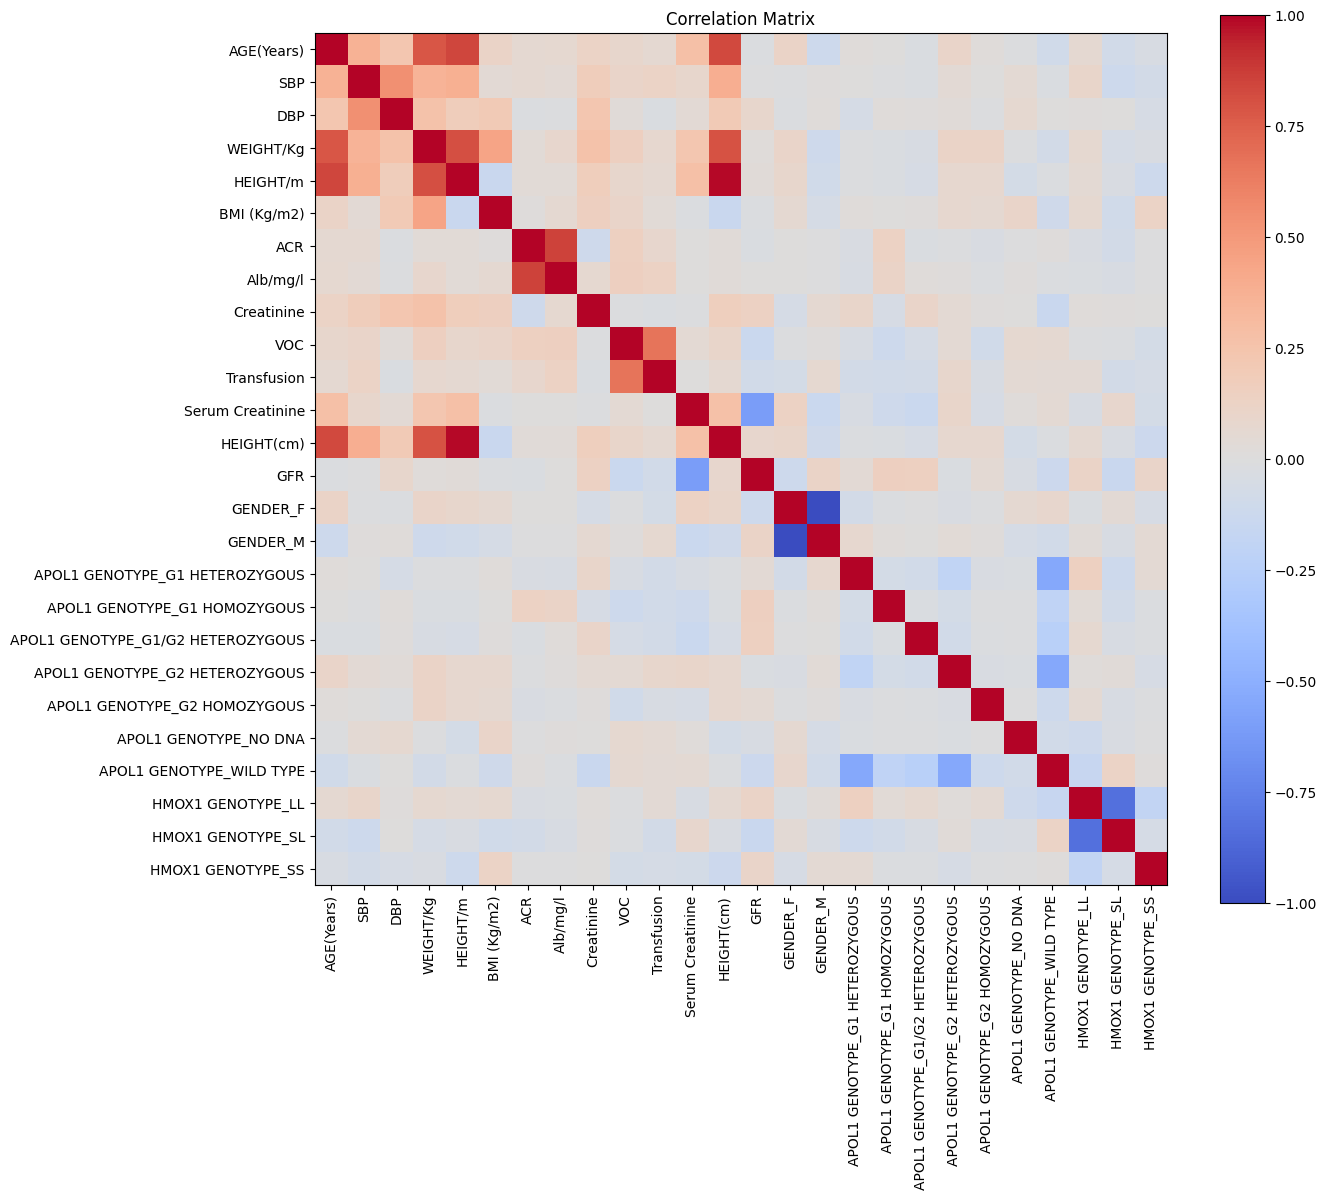

In [30]:
#check correlation of features with GFR and ACR
correlation_matrix = scd2.corr()
correlation_with_gfr = correlation_matrix['GFR'].sort_values(ascending=False)
print(correlation_with_gfr)
# Plot the correlation matrix
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None

plt.figure(figsize=(14,12))
if sns is not None:
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={'shrink': 0.8})
else:
    plt.imshow(correlation_matrix, interpolation='nearest', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
    plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()


In [ ]:
X = scd2.drop(columns=["GFR"])
y = scd2['GFR']
X = X.dropna(axis=0, how='any')
#X.info()
X_train_df, X_test_df, Y_train_df, Y_test_df = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_df.info()

mlflow.sklearn.autolog()
model = linear_model.LinearRegression()
fitted_model = model.fit(X_train_df, Y_train_df)
print("Fitted model object:", fitted_model)
print("Coefficients:", fitted_model.coef_)
print("Intercept:", fitted_model.intercept_)
print("Train R^2:", fitted_model.score(X_train_df, Y_train_df))
print("Test R^2:", fitted_model.score(X_test_df, Y_test_df))

2026/06/03 10:34:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f3e1365df5074b888aa020f47284d217', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/06/03 10:34:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing V

<class 'pandas.core.frame.DataFrame'>
Index: 151 entries, 106 to 104
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   AGE(Years)                         151 non-null    int64  
 1   SBP                                151 non-null    int64  
 2   DBP                                151 non-null    int64  
 3   WEIGHT/Kg                          151 non-null    float64
 4   HEIGHT/m                           151 non-null    float64
 5   BMI (Kg/m2)                        151 non-null    float64
 6   ACR                                151 non-null    float64
 7   Alb/mg/l                           151 non-null    float64
 8   Creatinine                         151 non-null    float64
 9   VOC                                151 non-null    int64  
 10  Transfusion                        151 non-null    int64  
 11  Serum Creatinine                   151 non-null    float64
 1

2026/06/03 10:34:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 10:34:37 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_

Fitted model object: LinearRegression()
Coefficients: [-9.21592672e-01 -2.25805118e-01  4.17954519e-01  6.49448734e-01
 -6.47839537e+02 -8.82761510e-01 -6.64609576e-02  2.18131461e-02
 -1.02288542e-02 -3.66405586e+00 -3.36439221e-01 -2.96177115e+02
  7.56950690e+00 -3.62486470e+00  3.62486470e+00  4.35312888e+00
  5.36005968e+01 -1.57373252e+01 -7.79473801e+00 -3.18319123e+01
  0.00000000e+00 -2.58975019e+00  5.03333454e+00  3.76455722e+00
  1.77373212e+01]
Intercept: 145.2626934083586
Train R^2: 0.7869090833776882
Test R^2: -0.22464418634359617


In [31]:
alpha_values = [0.01, 0.05, 0.1, 0.5, 1.0]
for alpha in alpha_values:
    with mlflow.start_run():
        mlflow.set_tag('developer','Oluyomi')
        #mlflow.log_param('train-data-path', 'data/yellow_tripdata_2023-01.parquet')
        #mlflow.log_param('valid-data-path', 'data/yellow_tripdata_2023-02.parquet')
        alpha=0.01
        ls = linear_model.Lasso(alpha=alpha)
        ls.fit(X_train_df, Y_train_df)
        ls_rmse = mean_squared_error(Y_train_df, ls.predict(X_train_df))
        mlflow.log_metric('rmse',ls_rmse)
        print("Linear Regression MSE:", ls_rmse)
        print("Coefficients:", ls.coef_)
        print("Intercept:", ls.intercept_)
        print("Train R^2:", ls.score(X_train_df, Y_train_df))
        print("Test R^2:", ls.score(X_test_df, Y_test_df))

2026/06/03 10:53:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/03 10:53:55 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site

Linear Regression MSE: 1348.9044464306714
Coefficients: [-9.58203196e-01 -2.26049125e-01  4.24067411e-01  5.19318420e-01
 -6.35880627e+02 -6.57106571e-01 -6.80573052e-02  2.35103662e-02
 -1.08516435e-02 -3.59916979e+00 -3.49157546e-01 -2.95922788e+02
  7.50932956e+00 -7.20906017e+00  4.31854910e-15  7.46319292e+00
  5.62118408e+01 -1.23345689e+01 -4.59929508e+00 -2.77382126e+01
  0.00000000e+00  4.72470185e-01  4.20730520e+00  2.88679441e+00
  1.53855412e+01]
Intercept: 138.7416918870412
Train R^2: 0.7868796270831365
Test R^2: -0.22379681701800092


2026/06/03 10:54:14 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`
2026/06/03 10:54:14 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing va

Linear Regression MSE: 1348.9044464306714
Coefficients: [-9.58203196e-01 -2.26049125e-01  4.24067411e-01  5.19318420e-01
 -6.35880627e+02 -6.57106571e-01 -6.80573052e-02  2.35103662e-02
 -1.08516435e-02 -3.59916979e+00 -3.49157546e-01 -2.95922788e+02
  7.50932956e+00 -7.20906017e+00  4.31854910e-15  7.46319292e+00
  5.62118408e+01 -1.23345689e+01 -4.59929508e+00 -2.77382126e+01
  0.00000000e+00  4.72470185e-01  4.20730520e+00  2.88679441e+00
  1.53855412e+01]
Intercept: 138.7416918870412
Train R^2: 0.7868796270831365
Test R^2: -0.22379681701800092


2026/06/03 10:54:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/03 10:54:18 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_

Linear Regression MSE: 1348.9044464306714
Coefficients: [-9.58203196e-01 -2.26049125e-01  4.24067411e-01  5.19318420e-01
 -6.35880627e+02 -6.57106571e-01 -6.80573052e-02  2.35103662e-02
 -1.08516435e-02 -3.59916979e+00 -3.49157546e-01 -2.95922788e+02
  7.50932956e+00 -7.20906017e+00  4.31854910e-15  7.46319292e+00
  5.62118408e+01 -1.23345689e+01 -4.59929508e+00 -2.77382126e+01
  0.00000000e+00  4.72470185e-01  4.20730520e+00  2.88679441e+00
  1.53855412e+01]
Intercept: 138.7416918870412
Train R^2: 0.7868796270831365
Test R^2: -0.22379681701800092


2026/06/03 10:54:24 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`
2026/06/03 10:54:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing va

Linear Regression MSE: 1348.9044464306714
Coefficients: [-9.58203196e-01 -2.26049125e-01  4.24067411e-01  5.19318420e-01
 -6.35880627e+02 -6.57106571e-01 -6.80573052e-02  2.35103662e-02
 -1.08516435e-02 -3.59916979e+00 -3.49157546e-01 -2.95922788e+02
  7.50932956e+00 -7.20906017e+00  4.31854910e-15  7.46319292e+00
  5.62118408e+01 -1.23345689e+01 -4.59929508e+00 -2.77382126e+01
  0.00000000e+00  4.72470185e-01  4.20730520e+00  2.88679441e+00
  1.53855412e+01]
Intercept: 138.7416918870412
Train R^2: 0.7868796270831365
Test R^2: -0.22379681701800092


2026/06/03 10:54:28 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during sklearn autologging: When an mlflow-artifacts URI was supplied, the tracking URI must be a valid http or https URI, but it was currently set to sqlite:/mlflow.db. Perhaps you forgot to set the tracking URI to the running MLflow server. To set the tracking URI, use either of the following methods:
1. Set the MLFLOW_TRACKING_URI environment variable to the desired tracking URI. `export MLFLOW_TRACKING_URI=http://localhost:5000`
2. Set the tracking URI programmatically by calling `mlflow.set_tracking_uri`. `mlflow.set_tracking_uri('http://localhost:5000')`


Linear Regression MSE: 1348.9044464306714
Coefficients: [-9.58203196e-01 -2.26049125e-01  4.24067411e-01  5.19318420e-01
 -6.35880627e+02 -6.57106571e-01 -6.80573052e-02  2.35103662e-02
 -1.08516435e-02 -3.59916979e+00 -3.49157546e-01 -2.95922788e+02
  7.50932956e+00 -7.20906017e+00  4.31854910e-15  7.46319292e+00
  5.62118408e+01 -1.23345689e+01 -4.59929508e+00 -2.77382126e+01
  0.00000000e+00  4.72470185e-01  4.20730520e+00  2.88679441e+00
  1.53855412e+01]
Intercept: 138.7416918870412
Train R^2: 0.7868796270831365
Test R^2: -0.22379681701800092


In [37]:
#build a random forest regression model and compare performance to linear regression
with mlflow.start_run():
    mlflow.set_tag('developer','Oluyomi')
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train_df, Y_train_df)
    rf_predictions = rf_model.predict(X_test_df)
    rf_mse = mean_squared_error(Y_test_df, rf_predictions)
    mlflow.log_metric('mse', rf_mse)
    print("Random Forest Regression R^2:", rf_model.score(X_test_df, Y_test_df))
    print("Random Forest Regression train R^2:", rf_model.score(X_train_df, Y_train_df))
    mlflow.log_metric('r2', rf_model.score(X_test_df, Y_test_df))
    mlflow.log_metric('train_r2', rf_model.score(X_train_df, Y_train_df))
    #mlflow.log_metric('feature_importances', rf_model.feature_importances_)

2026/06/03 11:13:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/06/03 11:13:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/usr/local/python/3.12.1/lib/python3.12/site

Random Forest Regression R^2: 0.9408727597625929
Random Forest Regression train R^2: 0.9821021406162888
